In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')

# настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

from src.config.settings import config

загрузка данных

In [32]:
df = pd.read_csv(config.PATH_RAG_READY_PAPERS_CSV)
print(f"загружено {len(df)} статей")
print(f"колонки: {df.columns.tolist()}")

загружено 41 статей
колонки: ['pmid', 'title', 'cleaned_abstract', 'cleaned_text', 'year', 'has_full_text']


In [33]:
# базовая информация о данных
print("=== Информация о данных ===\n")
df.info()

print("\n=== Статистика по годам ===")
if 'year' in df.columns:
    print(f"диапазон годов: {df['year'].min()} - {df['year'].max()}")
    print(f"статей с полным текстом: {df['has_full_text'].sum() if 'has_full_text' in df.columns else 'N/A'}")

=== Информация о данных ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   pmid              41 non-null     int64 
 1   title             41 non-null     object
 2   cleaned_abstract  41 non-null     object
 3   cleaned_text      41 non-null     object
 4   year              41 non-null     int64 
 5   has_full_text     41 non-null     bool  
dtypes: bool(1), int64(2), object(3)
memory usage: 1.8+ KB

=== Статистика по годам ===
диапазон годов: 2003 - 2025
статей с полным текстом: 18


распределение количества слов

In [35]:
def get_word_count(text):
    return len(str(text).split())

def get_sentence_count(text):
    import re
    sentences = re.split(r'[.!?]+', str(text))
    return len([s for s in sentences if s.strip()])

df['word_count'] = df['cleaned_text'].apply(get_word_count)
df['sentence_count'] = df['cleaned_text'].apply(get_sentence_count)
df['words_per_sentence'] = df['word_count'] / df['sentence_count']

print(f"добавлены колонки: word_count, sentence_count, words_per_sentence")
print(f"средняя длина статьи: {df['word_count'].mean():.0f} слов")

добавлены колонки: word_count, sentence_count, words_per_sentence
средняя длина статьи: 377 слов


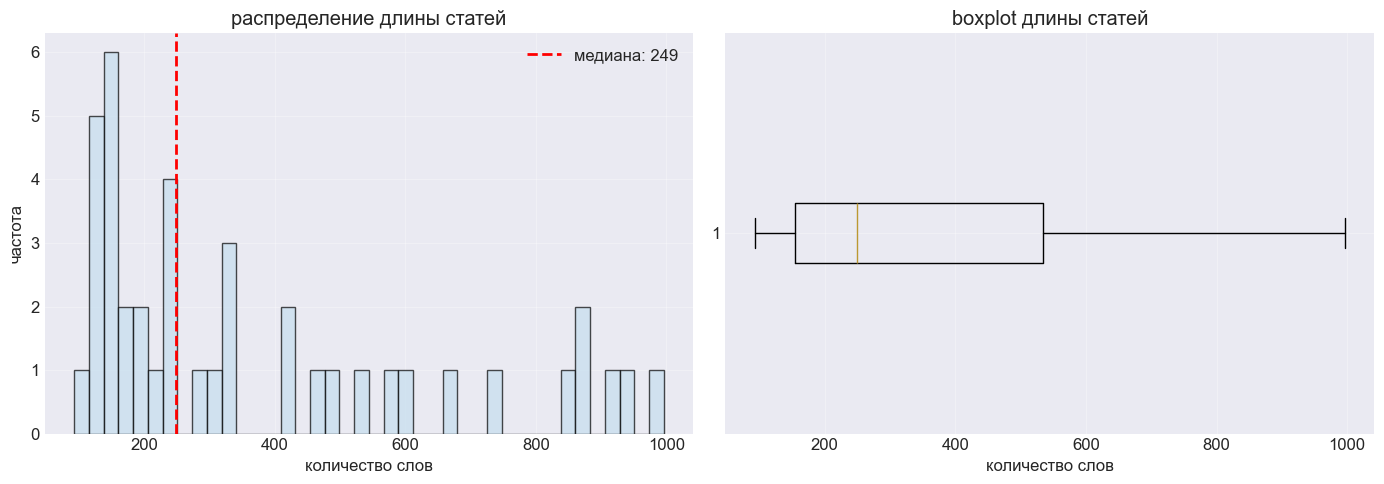

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# гистограмма
axes[0].hist(df['word_count'].dropna(), bins=40, color='#C5DEEF', edgecolor='black', alpha=0.7)
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--', linewidth=2, 
                   label=f'медиана: {df["word_count"].median():.0f}')
axes[0].set_xlabel('количество слов')
axes[0].set_ylabel('частота')
axes[0].set_title('распределение длины статей')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# boxplot
axes[1].boxplot(df['word_count'].dropna(), vert=False)
axes[1].set_xlabel('количество слов')
axes[1].set_title('boxplot длины статей')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/eda_results/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

медиана: 249 слов - преобладают аннотации (абстракты)

Q1 ≈ 160 слов
Q3 ≈ 570 слов

размах (max - min): около 800 слов

асимметрия:
- ящик смещен вверх (медиана ближе к Q1), правая граница длиннее левой
- распределение имеет правостороннюю асимметрию
- большинство статей короткие (преобладают абстракты), но есть несколько длинных 

выбросы:
- нет явных выбросов за пределами усов

выводы для RAG:
- типичная статья: 150-330 слов
- оптимальный размер чанка: 250-300 слов

короткие статьи (<150 слов) - использовать целиком
длинные статьи (>330 слов) - разбивать на чанки

анализ частоты слов (без стоп-слов)

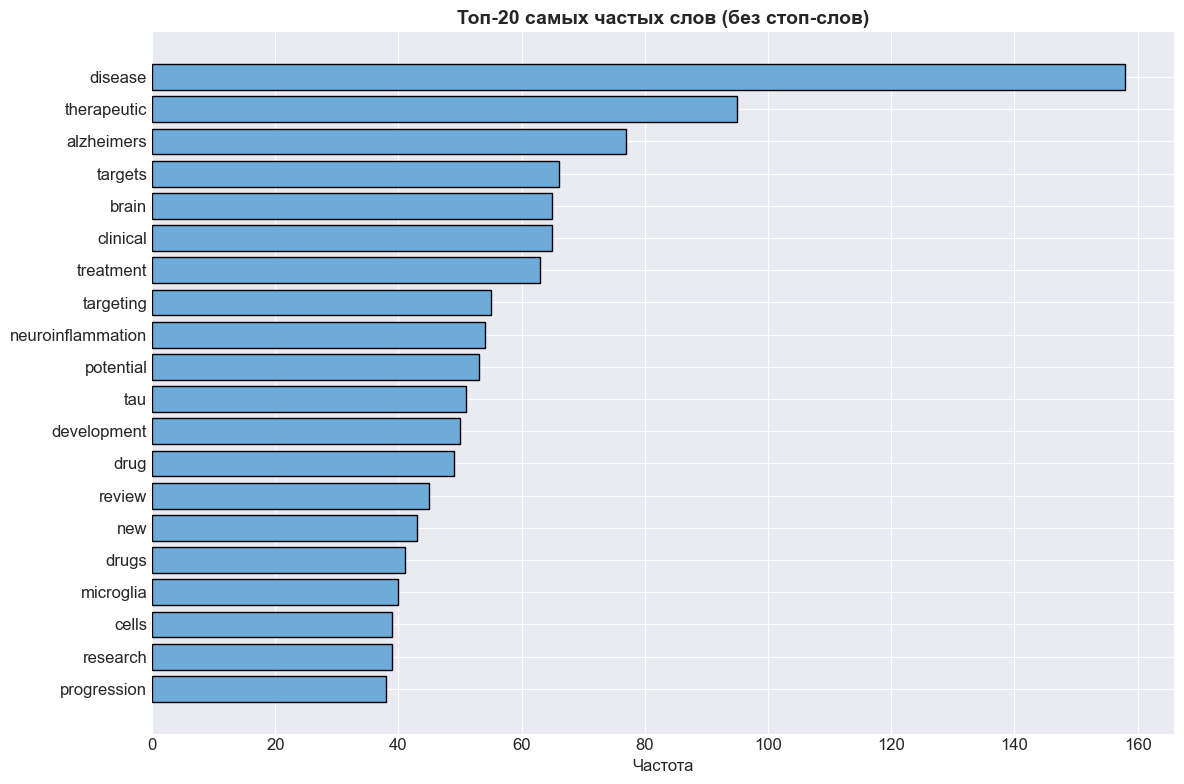


Топ-10 слов:
  disease: 158
  therapeutic: 95
  alzheimers: 77
  targets: 66
  brain: 65
  clinical: 65
  treatment: 63
  targeting: 55
  neuroinflammation: 54
  potential: 53


In [38]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# объединяем все тексты
all_text = ' '.join(df['cleaned_text'].dropna())
words = [w.lower() for w in nltk.word_tokenize(all_text) if w.isalpha() and len(w) > 2]
content_words = [w for w in words if w not in stop_words]

# частотный анализ
word_freq = Counter(content_words)
top_words = word_freq.most_common(20)

# визуализация
fig, ax = plt.subplots(figsize=(12, 8))
words_top, counts_top = zip(*top_words)

bars = ax.barh(range(len(words_top)), counts_top, color='#6EABD9', edgecolor='black')
ax.set_yticks(range(len(words_top)))
ax.set_yticklabels(words_top)
ax.set_xlabel('Частота')
ax.set_title('Топ-20 самых частых слов (без стоп-слов)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('results/eda_results/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nТоп-10 слов:")
for word, count in top_words[:10]:
    print(f"  {word}: {count}")

анализ биграмм

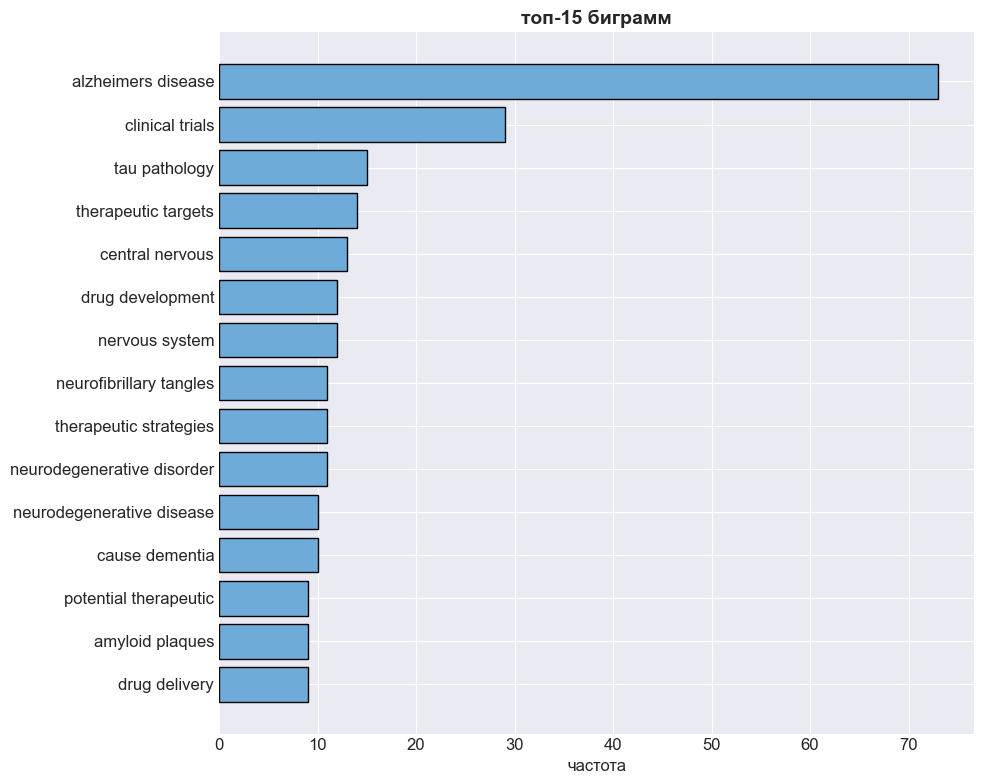


топ-10 биграмм:
  alzheimers disease: 73
  clinical trials: 29
  tau pathology: 15
  therapeutic targets: 14
  central nervous: 13
  drug development: 12
  nervous system: 12
  neurofibrillary tangles: 11
  therapeutic strategies: 11
  neurodegenerative disorder: 11


In [41]:
from nltk.util import ngrams

# биграммы
bigrams = list(ngrams(content_words, 2))
bigram_freq = Counter([' '.join(bg) for bg in bigrams if not any(w in stop_words for w in bg)])
top_bigrams = bigram_freq.most_common(15)

# визуализация
fig, ax = plt.subplots(figsize=(10, 8))
bg_words, bg_counts = zip(*top_bigrams)

ax.barh(range(len(bg_words)), bg_counts, color='#6EABD9', edgecolor='black')
ax.set_yticks(range(len(bg_words)))
ax.set_yticklabels(bg_words)
ax.set_xlabel('частота')
ax.set_title('топ-15 биграмм', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('results/eda_results/top_2grams.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nтоп-10 биграмм:")
for bg, count in top_bigrams[:10]:
    print(f"  {bg}: {count}")

можно учитывать при разбивке на чанки и создании эмбеддингов

облако слов

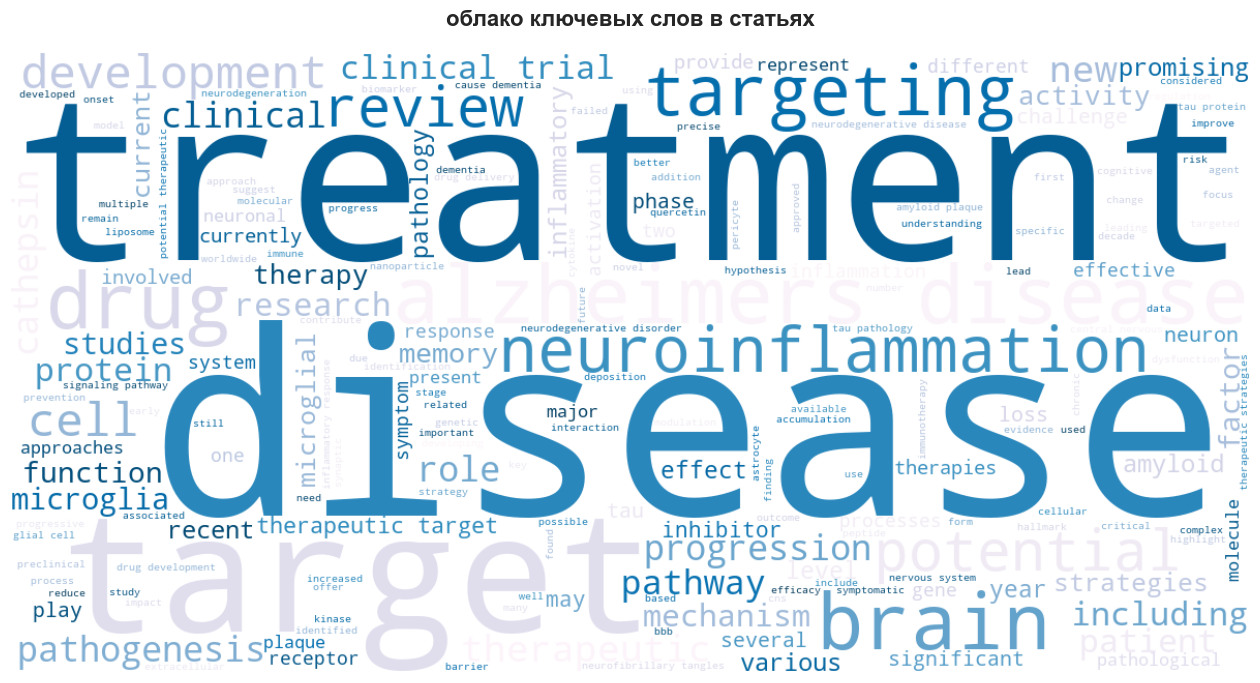

In [42]:
wordcloud = WordCloud(width=1200, height=600, 
                     background_color='white',
                     max_words=200,
                     colormap='PuBu',
                     contour_width=1,
                     contour_color='steelblue').generate(' '.join(content_words))

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('облако ключевых слов в статьях', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('results/eda_results/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

анализ по годам 

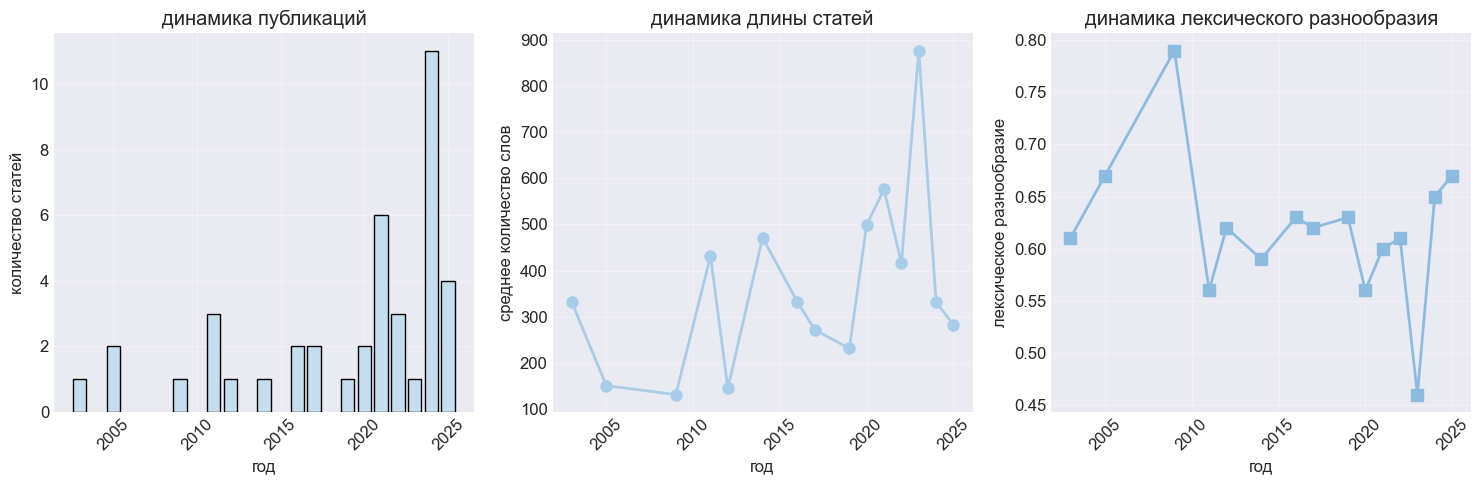


=== Статистика по годам ===
 year  avg_words  num_articles  avg_diversity
 2003     332.00             1           0.61
 2005     150.50             2           0.67
 2009     131.00             1           0.79
 2011     431.33             3           0.56
 2012     145.00             1           0.62
 2014     471.00             1           0.59
 2016     332.50             2           0.63
 2017     272.00             2           0.62
 2019     231.00             1           0.63
 2020     499.50             2           0.56
 2021     576.17             6           0.60
 2022     416.00             3           0.61
 2023     877.00             1           0.46
 2024     331.27            11           0.65
 2025     282.25             4           0.67


In [46]:
df['unique_words'] = df['cleaned_text'].apply(lambda x: len(set(str(x).split())))
df['lexical_diversity'] = df['unique_words'] / df['word_count']
df['lexical_diversity'] = df['lexical_diversity'].fillna(0).replace([float('inf'), -float('inf')], 0)

if 'year' in df.columns:
    yearly_stats = df.groupby('year').agg({
        'word_count': ['mean', 'count'],
        'lexical_diversity': 'mean'
    }).round(2)
    yearly_stats.columns = ['avg_words', 'num_articles', 'avg_diversity']
    yearly_stats = yearly_stats.reset_index()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].bar(yearly_stats['year'], yearly_stats['num_articles'], color='#C5DEEF', edgecolor='black')
    axes[0].set_xlabel('год')
    axes[0].set_ylabel('количество статей')
    axes[0].set_title('динамика публикаций')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(yearly_stats['year'], yearly_stats['avg_words'], marker='o', linewidth=2, markersize=8, color='#A8CDE8')
    axes[1].set_xlabel('год')
    axes[1].set_ylabel('среднее количество слов')
    axes[1].set_title('динамика длины статей')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(yearly_stats['year'], yearly_stats['avg_diversity'], marker='s', linewidth=2, markersize=8, color='#8BBCE0')
    axes[2].set_xlabel('год')
    axes[2].set_ylabel('лексическое разнообразие')
    axes[2].set_title('динамика лексического разнообразия')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/eda_results/yearly_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n=== Статистика по годам ===")
    print(yearly_stats.to_string(index=False))
else:
    print("нет данных по годам для анализа")

собрано недостаточно статей для анализа динамики по годам, большая часть статей в датасете за 2024 год

корреляционный анализ метрик

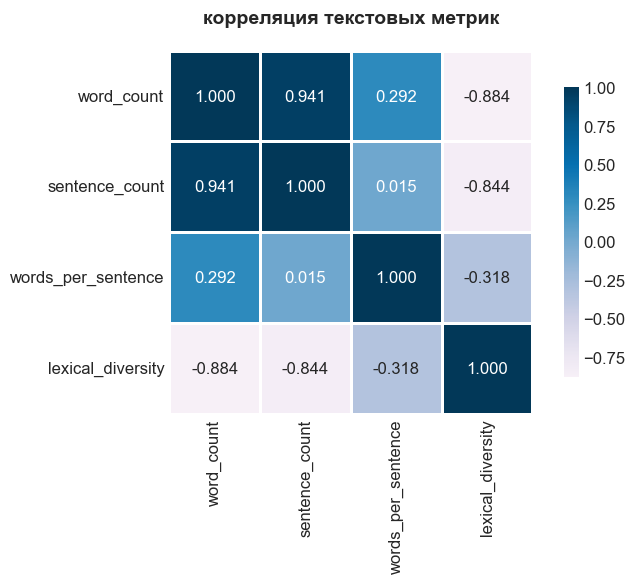


=== Коэффициенты корреляции ===
                    word_count  sentence_count  words_per_sentence  \
word_count               1.000           0.941               0.292   
sentence_count           0.941           1.000               0.015   
words_per_sentence       0.292           0.015               1.000   
lexical_diversity       -0.884          -0.844              -0.318   

                    lexical_diversity  
word_count                     -0.884  
sentence_count                 -0.844  
words_per_sentence             -0.318  
lexical_diversity               1.000  


In [47]:
metrics = ['word_count', 'sentence_count', 'words_per_sentence', 'lexical_diversity']
corr_matrix = df[metrics].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='PuBu', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', annot_kws={'size': 12})
ax.set_title('корреляция текстовых метрик', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('results/eda_results/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Коэффициенты корреляции ===")
print(corr_matrix.round(3))

sentence_count - word_count  0.941 (сильная положительная коррелляция): длинные статьи => больше предложений 

lexical_diversity - word_count  -0.884 (сильная отрицательная коррелляция): длинные статьи => меньше лексическое разнообразие 

объясняется тем, что есть два типа документов:

аннотации (высокое разнообразие, мало повторов)
полные тексты (низкое разнообразие, много повторов)

итоговая статистика и сохранение результатов

In [49]:
print(f"\n Общая информация:")
print(f"  • всего статей: {len(df)}")
print(f"  • уникальных PMID: {df['pmid'].nunique() if 'pmid' in df.columns else 'N/A'}")
print(f"  • полнотекстовых статей: {df['has_full_text'].sum() if 'has_full_text' in df.columns else 'N/A'}")

print(f"\n Текстовые метрики (медиана):")
print(f"  • количество слов: {df['word_count'].median():.0f}")
print(f"  • лексическое разнообразие: {df['lexical_diversity'].median():.3f}")

print(f"\n Топ-5 ключевых слов:")
for word, count in top_words[:5]:
    print(f"  • {word}: {count}")

print(f"\n Годовая статистика:")
if 'year' in df.columns:
    print(f"  • период: {df['year'].min()} - {df['year'].max()}")
    print(f"  • год с максимумом статей: {df['year'].mode()[0]} ({df[df['year']==df['year'].mode()[0]].shape[0]} статей)")

# Сохраняем обогащенный датафрейм
df.to_csv(config.PATH_PAPERS_WITH_METRICS_CSV, index=False)
print(f"\n датафрейм сохранен в {config.PATH_PAPERS_WITH_METRICS_CSV}")
print(f" графики сохранены в 'results/eda_results/'")


 Общая информация:
  • всего статей: 41
  • уникальных PMID: 41
  • полнотекстовых статей: 18

 Текстовые метрики (медиана):
  • количество слов: 249
  • лексическое разнообразие: 0.621

 Топ-5 ключевых слов:
  • disease: 158
  • therapeutic: 95
  • alzheimers: 77
  • targets: 66
  • brain: 65

 Годовая статистика:
  • период: 2003 - 2025
  • год с максимумом статей: 2024 (11 статей)

 датафрейм сохранен в data/processed/alzheimer_papers_with_metrics.csv
 графики сохранены в 'results/eda_results/'


лексическое разнообразие оптимально, приемлемое соотношение абстрактов и полнотекстовых статей 
(62.1 % слов встречаются 1 раз)